In [1]:
%reset -f

In [2]:
import numpy as np
from tqdm import tqdm
import scipy.linalg as la
import numpy.linalg as npla

import torch
import normflows as nf

import sys
sys.path.append('/Users/adithya/Documents/flow-pid')
import pid
import pid.utils.distributions as dist
from pid.utils.generate import sample_mult_poisson
from pid.utils.custom_flow import CartesianProductFlow

In [3]:
def get_params():
    lamda_m = np.array([2., 2.])
    lamda_x = np.array([1.,])      # Noise to be added to X: shape (d_X,)
    lamda_y = np.array([1.,])

    w_x1_vals = np.arange(11) / 10
    w_x2 = 0.5
    w_y1 = 0.5
    w_y2 = 0.5

    return lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2

In [13]:
def objective(sig, hx, hy, dm, dx, dy, reg):
    S = (1 + reg) * np.eye(dx) - sig @ sig.T
    B = hx - sig @ hy
    obj = 0.5 / np.log(2) * npla.slogdet(
        np.eye(dm) + hy.T @ hy + B.T @ la.solve(S, B)
    )[1]
    return obj

def covariance_to_correlation(covariance_matrix):
    covariance_matrix = np.array(covariance_matrix)
    
    if covariance_matrix.shape[0] != covariance_matrix.shape[1]:
        raise ValueError("Covariance matrix must be square")
    
    if not np.allclose(covariance_matrix, covariance_matrix.T):
        raise ValueError("Covariance matrix must be symmetric")
    
    std_devs = np.sqrt(np.diag(covariance_matrix))  
    outer_std = np.outer(std_devs, std_devs)
    correlation_matrix = covariance_matrix / outer_std 
    np.fill_diagonal(correlation_matrix, 1.0)
    
    return correlation_matrix

In [35]:
num_samples=1000
flow_iter=1000
n_flows=1

enable_cuda=True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(f"Using device: {device}")

lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2 = get_params()
dm = lamda_m.size  # Number of dimensions of M
dx = lamda_x.size  # Number of dimensions of X
dy = lamda_y.size  # Number of dimensions of Y

Using device: cpu


In [36]:
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt



def train_flow(m_data, x_data, y_data, n_epochs=100, batch_size=64, lr=2e-4):
    # Initialize model
    dim_x, dim_y, dim_m = x_data.shape[1], y_data.shape[1], m_data.shape[1]
    flow = CartesianProductFlow(dim_m, dim_x, dim_y, n_flows)
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    
    # Create dataset
    print(x_data.shape, y_data.shape, m_data.shape)
    dataset = TensorDataset(torch.tensor(x_data,dtype=torch.float32), torch.tensor(y_data,dtype=torch.float32), torch.tensor(m_data,dtype=torch.float32))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    losses = []
    
    for epoch in tqdm(range(n_epochs)):
        epoch_losses = []
        
        for x_batch, y_batch, m_batch in dataloader:
            optimizer.zero_grad()
            
            # Forward pass
            z_m, z_x, z_y, log_det = flow(m_batch, x_batch, y_batch)
            
            # Compute loss
            loss = flow.compute_loss(z_m, z_x, z_y, log_det)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)
        
        with torch.no_grad():
            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")
                
                # Print learned parameters
                # print(f"Learned mean: {flow.estimate_latent_mean(z_m, z_x, z_y).data}")
                # print(f"Learned covariance:\n{flow.estimate_latent_cov(z_m, z_x, z_y).data}")

                if epoch > 30:
                    cov = flow.estimate_latent_cov(z_m, z_x, z_y).detach().cpu().numpy()
                    cov = covariance_to_correlation(cov)
                    print(f"Learned covariance:\n{cov}")
                    # ret = pid.utils.whiten(cov, dm, dx, dy, ret_channel_params=True)
                    # sig_mxy, hx, hy, hxy, sigxy = ret
                    # sig, obj, _ = pid.optimizers.thinpid_exact_pid_minimizer(hx, hy, ret_obj=True, reg=1e-7)
                    # union_info = objective(sig, hx, hy, dm, dx, dy, reg=1e-7)
                    # print(f"Union information:{union_info}")
                    ret = exact_gauss_tilde_pid(cov, dm, dx, dy)

                    print("pid: ", ret[7], ret[5], ret[6], ret[8])
    
    # Plot loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()
    
    return flow, losses

(1000, 1) (1000, 1) (1000, 2)


  5%|▌         | 52/1000 [00:02<00:50, 18.95it/s]

Epoch 50/1000, Loss: 54.3299
Learned covariance:
[[ 1.         -0.19009966  0.5461286   0.37305185]
 [-0.19009966  1.          0.28461623  0.280284  ]
 [ 0.5461286   0.28461623  1.          0.39521644]
 [ 0.37305185  0.280284    0.39521644  1.        ]]
pid:  0.2157555747191962 0.221809167312943 0.008433970005404967 0.0977638330237513


 10%|█         | 102/1000 [00:05<00:45, 19.57it/s]

Epoch 100/1000, Loss: 45.8618
Learned covariance:
[[ 1.         -0.00905897  0.5837115   0.3703031 ]
 [-0.00905897  1.          0.32508582  0.29854476]
 [ 0.5837115   0.32508582  1.          0.36161923]
 [ 0.3703031   0.29854476  0.36161923  1.        ]]
pid:  0.17781205142068163 0.25327209217281066 0.009108729223774592 0.08027870022147438


...

Epoch 900/1000, Loss: 26.0547
Learned covariance:
[[1.         0.37263045 0.63663673 0.42123702]
 [0.37263045 1.         0.42848122 0.38474873]
 [0.63663673 0.42848122 1.         0.36561877]
 [0.42123702 0.38474873 0.36561877 1.        ]]
pid:  0.18025908476364844 0.2480848161611607 0.015517798709224428 0.08051945615107353


 95%|█████████▌| 951/1000 [00:47<00:02, 19.87it/s]

Epoch 950/1000, Loss: 25.5615
Learned covariance:
[[1.         0.20643468 0.5888873  0.39726666]
 [0.20643468 1.         0.3922131  0.334308  ]
 [0.5888873  0.3922131  1.         0.36978123]
 [0.39726666 0.334308   0.36978123 1.        ]]
pid:  0.17702142743509397 0.22002952542750268 0.0062012746664165674 0.07769912923621453


100%|██████████| 1000/1000 [00:49<00:00, 20.15it/s]


Epoch 1000/1000, Loss: 25.4409
Learned covariance:
[[1.         0.16989475 0.6134397  0.39858314]
 [0.16989475 1.         0.39758068 0.36676508]
 [0.6134397  0.39758068 1.         0.37366945]
 [0.39858314 0.36676508 0.37366945 1.        ]]
pid:  0.19395248226675293 0.25714302732180894 0.014486500014048664 0.08818627801361573


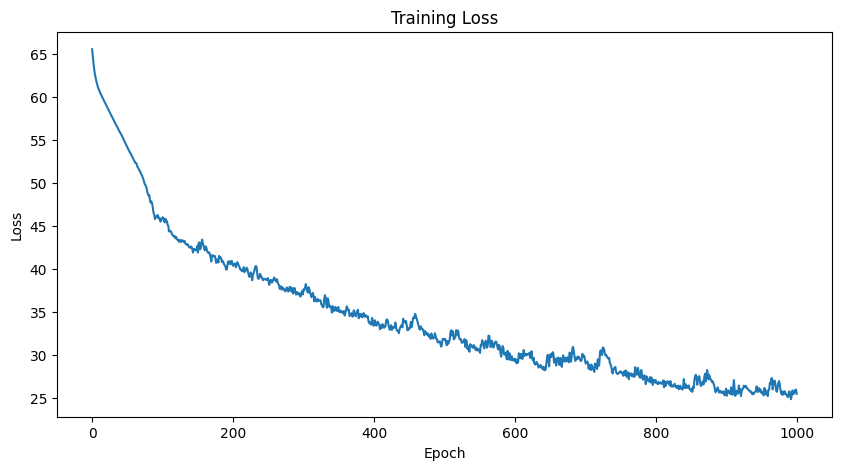

In [37]:
w_x1 = w_x1_vals[9]
w_x = np.array([[w_x1, w_x2]])  # Binomial thinning weights: shape (dx, dm)
w_y = np.array([[w_y1, w_y2]])
m, x, y = sample_mult_poisson(num_samples, lamda_m, w_x, w_y, lamda_x, lamda_y)  # Shape: (d, n)


trained_flow, training_losses = train_flow(m.T, x.T, y.T, n_epochs=1000, batch_size=1000, lr=1e-4)

(1000, 1) (1000, 1) (1000, 2)


  5%|▌         | 50/1000 [00:04<01:28, 10.73it/s]

Epoch 50/1000, Loss: 35.9552
Learned covariance:
[[ 1.         -0.13774288 -0.07358336  0.31863827]
 [-0.13774288  1.          0.45811036  0.31159738]
 [-0.07358336  0.45811036  1.          0.17886862]
 [ 0.31863827  0.31159738  0.17886862  1.        ]]
pid:  0.04003712788931696 0.1299796902398117 0.14882163996892483 0.018480326306819894


 10%|█         | 100/1000 [00:09<01:25, 10.55it/s]

Epoch 100/1000, Loss: 28.3399
Learned covariance:
[[ 1.         -0.01922941 -0.03076927  0.31951222]
 [-0.01922941  1.          0.4064153   0.30785465]
 [-0.03076927  0.4064153   1.          0.15697707]
 [ 0.31951222  0.30785465  0.15697707  1.        ]]
pid:  0.03395188011481126 0.09672943670821169 0.12766136652276572 0.017629409957945985


...

Epoch 900/1000, Loss: 15.4714
Learned covariance:
[[1.         0.03355421 0.04461776 0.3549681 ]
 [0.03355421 1.         0.40340108 0.31246024]
 [0.04461776 0.40340108 1.         0.16371354]
 [0.3549681  0.31246024 0.16371354 1.        ]]
pid:  0.046226736099996946 0.08272662246760482 0.1297100571100119 0.027429066046165962


 95%|█████████▌| 951/1000 [01:27<00:04, 10.32it/s]

Epoch 950/1000, Loss: 13.6848
Learned covariance:
[[ 1.          0.04639313 -0.03957304  0.3379462 ]
 [ 0.04639313  1.          0.4048511   0.352195  ]
 [-0.03957304  0.4048511   1.          0.16797788]
 [ 0.3379462   0.352195    0.16797788  1.        ]]
pid:  0.03482129696446934 0.09725915462722184 0.15155773345420698 0.016369341379492086


100%|██████████| 1000/1000 [01:32<00:00, 10.87it/s]

Epoch 1000/1000, Loss: 14.2066
Learned covariance:
[[1.         0.07412829 0.02901404 0.39115763]
 [0.07412829 1.         0.39724118 0.32398155]
 [0.02901404 0.39724118 1.         0.16949907]
 [0.39115763 0.32398155 0.16949907 1.        ]]
pid:  0.0374914646598149 0.08639173700151276 0.16094907928943586 0.018358140859171146


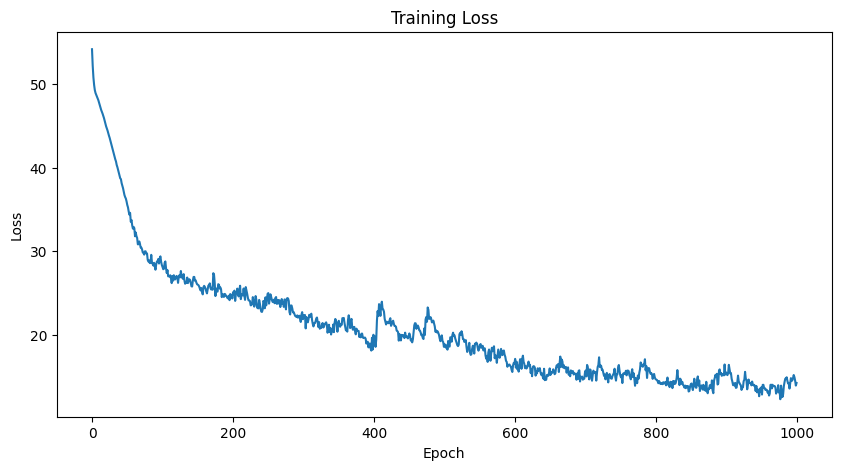

In [33]:
w_x1 = w_x1_vals[0]
w_x = np.array([[w_x1, w_x2]])  # Binomial thinning weights: shape (dx, dm)
w_y = np.array([[w_y1, w_y2]])
m, x, y = sample_mult_poisson(num_samples, lamda_m, w_x, w_y, lamda_x, lamda_y)  # Shape: (d, n)


trained_flow, training_losses = train_flow(m.T, x.T, y.T, n_epochs=1000, batch_size=1000, lr=1e-4)

In [39]:
from pid.optimizers import exact_gauss_tilde_pid, exact_tilde_union_info_minimizer
from pid.utils import whiten

mxy = np.vstack((m, x, y))
cov = np.corrcoef(mxy)    # Shape: (dm+dx+dy, dm+dx+dy)
print(cov)

# ret = whiten(cov, dm, dx, dy, ret_channel_params=True)
# sig_mxy, hx, hy, hxy, sigxy = ret
# print(sig_mxy)
# print(hx, hy)

ret = exact_gauss_tilde_pid(cov, dm, dx, dy)
# union_info = objective(sig, hx, hy, dm, dx, dy, reg=1e-7)

# print(union_info)
print(ret[7], ret[5], ret[6], ret[8])

[[1.         0.04563632 0.67734452 0.44496723]
 [0.04563632 1.         0.38178796 0.3725005 ]
 [0.67734452 0.38178796 1.         0.42210561]
 [0.44496723 0.3725005  0.42210561 1.        ]]
0.26268044729744433 0.3668200830160589 0.01795510821820412 0.12115846643669226
